# Análisis Predictivo de Precios de Vuelos
## Sistema de Recomendación basado en Machine Learning

**Autor:** Shiyi Cheng   
**Asignatura:** Reconocimiento de Formas y Aprendizaje automático

---

## Índice

1. [Introducción](#introduccion)
2. [Estado del Arte](#estado-del-arte)
3. [Análisis Exploratorio de Datos](#analisis-exploratorio)
4. [Metodología](#metodologia)
5. [Implementación de Modelos](#implementacion-modelos)
   - 5.1 [Modelos Lineales](#modelos-lineales)
   - 5.2 [Modelos Basados en Árboles](#modelos-arboles)
   - 5.3 [Redes Neuronales Simples](#redes-simples)
   - 5.4 [Redes Neuronales Profundas](#redes-profundas)
6. [Comparación de Resultados](#comparacion-resultados)
7. [Conclusiones](#conclusiones)
8. [Referencias](#referencias)

<a id="introduccion"></a>
## 1. Introducción

El proyecto aborda el problema de predicción de precios en el sector aeronáutico mediante técnicas de aprendizaje automático. El objetivo principal es desarrollar un sistema de recomendación que ayude a los usuarios a tomar decisiones informadas sobre la compra de billetes de avión.

### 1.1 Objetivo del Proyecto

Implementar y comparar diferentes algoritmos de machine learning para predecir si el precio actual de un vuelo está en zona óptima de compra, permitiendo así recomendar si es conveniente comprar o esperar.

### 1.2 Alcance

Este estudio compara siete algoritmos diferentes distribuidos en cuatro categorías:
- Modelos Lineales
- Redes Neuronales Simples
- Redes Neuronales Profundas
- Modelos No Paramétricos basados en Árboles

<a id="estado-del-arte"></a>
## 2. Estado del Arte

### 2.1 Contexto del Problema

La predicción de precios de vuelos es un problema clásico en el ámbito del revenue management y pricing dinámico. Las aerolíneas utilizan sistemas complejos para ajustar precios en función de múltiples variables:

- **Demanda anticipada**: Basada en históricos y tendencias
- **Días hasta la salida**: Factor crítico en la estrategia de pricing
- **Competencia**: Precios de otras aerolíneas en la misma ruta
- **Estacionalidad**: Temporada alta/baja
- **Capacidad disponible**: Asientos restantes

### 2.2 Trabajos Relacionados

#### 2.2.1 Enfoque de Regresión (Julien JTA, 2022)

En el trabajo "Flight Price Prediction - 98.47% R² Score" [1], se aborda el problema como una tarea de **regresión** para predecir el precio exacto del vuelo. 

**Problema que resuelve:**
- Predicción numérica del precio de vuelos basándose en características como aerolínea, origen, destino, clase, duración y número de escalas.

**Metodología:**
- Preprocesamiento exhaustivo con One-Hot Encoding para variables categóricas
- Comparación de múltiples modelos de regresión: Linear Regression, Decision Tree, Random Forest y Gradient Boosting
- Feature engineering para capturar interacciones entre variables

**Resultados principales:**
- **Random Forest alcanzó R² = 0.9847**, demostrando excelente capacidad predictiva
- Las variables más importantes fueron: aerolínea, clase, duración del vuelo y días hasta la salida
- El modelo captura bien la variabilidad de precios, pero requiere datos históricos completos

#### 2.2.2 Comparativa Exhaustiva de Modelos (Varun Saikanuri, 2022)

El trabajo "Flight Fare Prediction - 10 ML Models" [2] realiza una comparativa sistemática de algoritmos de machine learning para predicción de tarifas.

**Problema que resuelve:**
- Comparación empírica de 10 algoritmos diferentes para determinar cuál ofrece mejor rendimiento en predicción de precios de vuelos.

**Modelos evaluados:**
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regressor
5. Random Forest Regressor
6. Gradient Boosting Regressor
7. XGBoost Regressor
8. AdaBoost Regressor
9. K-Nearest Neighbors
10. Support Vector Regressor (SVR)

**Resultados principales:**
- **Random Forest y Gradient Boosting** mostraron mejor rendimiento con R² > 0.82
- Los modelos de ensemble superan consistentemente a modelos lineales
- El número de escalas y la duración del vuelo son predictores clave
- XGBoost ofreció el mejor balance entre precisión y tiempo de entrenamiento

**Conclusiones del estudio:**
- Los modelos basados en árboles (Random Forest, Gradient Boosting) son más efectivos para este problema debido a su capacidad de capturar relaciones no lineales
- La regularización (Ridge, Lasso) ayuda pero no es suficiente para modelos lineales
- El preprocesamiento adecuado de variables categóricas es crítico

### 2.3 Diferencias con Trabajos Previos

**Diferencias clave de este proyecto:**

1. **Enfoque de clasificación vs regresión:**
   - Trabajos anteriores predicen el precio exacto (regresión)
   - Este proyecto clasifica si el precio está en zona óptima de compra (clasificación binaria)
   - Ventaja: Proporciona recomendación accionable directa ("comprar ahora" vs "esperar")

2. **Cobertura de técnicas:**
   - Incluye modelos lineales, redes neuronales simples, redes profundas y métodos basados en árboles

3. **Enfoque práctico:**
   - Sistema de recomendación interpretable para usuarios finales
   - No requiere conocer la distribución completa de precios en tiempo real
   - Basado en aprendizaje de patrones históricos

### 2.4 Justificación del Enfoque

En este trabajo se adopta un enfoque de **clasificación binaria** en lugar de regresión por las siguientes razones:

- **Simplicidad interpretativa**: Para usuarios finales es más útil saber "comprar/esperar" que un precio exacto
- **Robustez**: Los modelos de clasificación son menos sensibles a outliers extremos en precios
- **Limitaciones del dataset**: Ausencia de series temporales completas para cada ruta
- **Utilidad práctica**: La decisión binaria es más accionable que una predicción de precio que puede variar rápidamente

### 2.5 Contribución de este Trabajo

- Comparativa sistemática de 7 algoritmos de 4 categorías diferentes
- Implementación completa del pipeline de ML
- Enfoque de clasificación basado en percentiles que balancea oportunidad y disponibilidad
- Análisis de importancia de características y visualizaciones comparativas
- Sistema de recomendación interpretable y aplicable a usuarios reales

<a id="analisis-exploratorio"></a>
## 3. Análisis Exploratorio de Datos

### 3.1 Carga de Librerías

Comenzamos importando las librerías necesarias para el análisis y modelado.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

### 3.2 Carga y Exploración Inicial del Dataset

In [ ]:
df = pd.read_csv('Clean_Dataset.csv')
print(df.head())

Primeras filas del dataset:
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


### 3.3 Limpieza de Datos

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [56]:
# Eliminación de columnas innecesarias
# 'Unnamed: 0' es un índice redundante
df = df.drop(['Unnamed: 0'], axis=1)

### 3.4 Estadística Descriptiva

In [57]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


### 3.5 Análisis de Correlaciones

In [58]:
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr().T

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


### 3.6 Análisis de Aerolíneas

Examinamos la distribución de vuelos por aerolínea para entender la composición del dataset.

In [ ]:
df1 = df.groupby(['flight','airline'], as_index=False).count()
print(df1.airline.value_counts())

Distribución de vuelos por aerolínea:
airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64


Indigo es la aerolínea con mayor número de vuelos en el dataset, lo que puede indicar mayor cuota de mercado en las rutas analizadas.

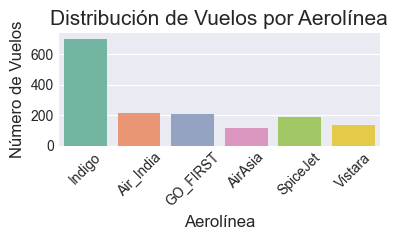

In [60]:
plt.figure(figsize=(4,2.5))
sns.countplot(x=df1['airline'], palette='Set2')
plt.title('Distribución de Vuelos por Aerolínea', fontsize=15)
plt.xlabel('Aerolínea', fontsize=12)
plt.ylabel('Número de Vuelos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.7 Relación entre Días Restantes y Precio

Analizamos cómo evoluciona el precio en función de los días que faltan para la salida del vuelo.

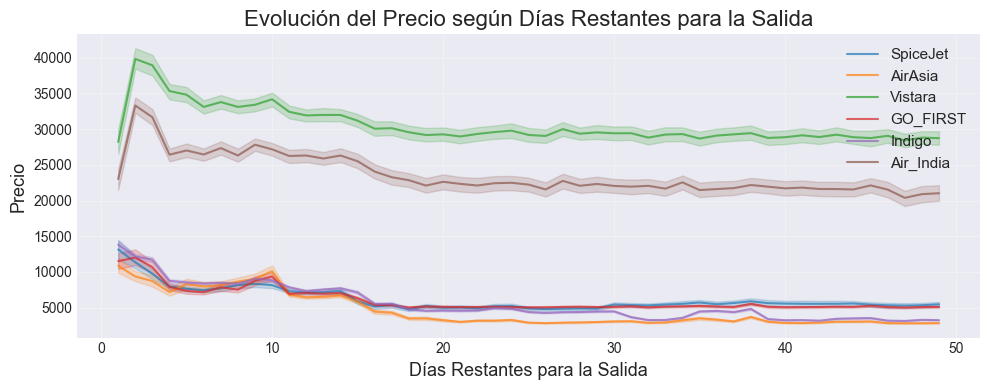

In [61]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='days_left', y='price', hue='airline', palette='tab10', alpha=0.7)
plt.title('Evolución del Precio según Días Restantes para la Salida', fontsize=16)
plt.legend(fontsize=11, loc='best')
plt.xlabel('Días Restantes para la Salida', fontsize=13)
plt.ylabel('Precio', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id="metodologia"></a>
## 4. Metodología

### 4.1 Construcción de la Variable Objetivo

El objetivo del modelo es predecir si un vuelo tiene un precio en zona de compra óptima, basándose en las características del vuelo (aerolínea, ruta, días de antelación, duración, escalas).

#### Definición de "Precio Óptimo"

Se considera que un precio está en zona de compra óptima cuando se encuentra en el 30% más bajo (percentil 30) de precios históricos para vuelos similares.

#### Construcción de la Variable (Evitando Data Leakage)

Para que el problema sea válido para ML, debemos:
- Calcular el umbral solo con datos de entrenamiento
- Aplicarlo consistentemente en train y test

#### Variable Objetivo

- `precio_optimo = 1`: Características típicas de vuelos en el 30% más bajo de precio (COMPRAR)
- `precio_optimo = 0`: Características típicas de vuelos con precio elevado (ESPERAR)

In [ ]:
# Creación de la variable objetivo
df_model = df.copy()

# Agrupamos por características clave del vuelo
group_cols = ['airline', 'source_city', 'destination_city', 'class']
df_model['precio_umbral_30'] = df_model.groupby(group_cols)['price'].transform(lambda x: x.quantile(0.30))

# Variable binaria: 1 si el precio actual está en el 30% más bajo (zona óptima)
df_model['precio_optimo'] = (df_model['price'] <= df_model['precio_umbral_30']).astype(int)

# Verificación de la distribución de clases
print("Distribución de la variable objetivo:")
print(df_model['precio_optimo'].value_counts())
print(f"\nProporción de precios óptimos: {df_model['precio_optimo'].mean():.2%}")

# Eliminamos 'price' antes de entrenar para que el modelo no pueda hacer trampa
# El modelo debe aprender de las características (días, aerolínea, ruta, etc.)
# NO del precio directamente
print("\nEliminamos 'price' del dataset de entrenamiento")
print("El modelo debe aprender patrones de características → precio_optimo")
print("NO puede simplemente calcular: price <= umbral")

# Eliminamos columnas no necesarias para el modelado
df_model = df_model.drop(['flight', 'price', 'precio_umbral_30'], axis=1)

Distribución de la variable objetivo:
precio_optimo
0    172621
1    127532
Name: count, dtype: int64

Proporción de precios óptimos: 42.49%

Eliminamos 'price' del dataset de entrenamiento
El modelo debe aprender patrones de características → precio_optimo
NO puede simplemente calcular: price <= umbral


In [63]:
# Demostración: Por qué necesitamos ML y no solo un bucle for

print("="*70)
print("POR QUÉ MACHINE LEARNING Y NO SOLO UN BUCLE FOR")
print("="*70)

# Ejemplo: Vuelos con características similares pero precios diferentes
ejemplo_grupo = df[
    (df['airline'] == 'Air_India') & 
    (df['source_city'] == 'Mumbai') &
    (df['destination_city'] == 'Delhi') &
    (df['class'] == 'Economy')
].copy()

if len(ejemplo_grupo) > 0:
    precio_p30 = ejemplo_grupo['price'].quantile(0.30)
    
    print(f"\nGrupo: Air India Mumbai → Delhi (Economy)")
    print(f"Umbral P30: ₹{precio_p30:,.0f}")
    
    # Dos vuelos con MISMAS características de grupo pero diferentes características individuales
    vuelos_optimos = ejemplo_grupo[ejemplo_grupo['price'] <= precio_p30].head(3)
    vuelos_caros = ejemplo_grupo[ejemplo_grupo['price'] > precio_p30].head(3)
    
    print(f"\nVuelos en zona ÓPTIMA (precio ≤ ₹{precio_p30:,.0f}):")
    for idx, row in vuelos_optimos.iterrows():
        print(f"   ₹{row['price']:>6,.0f} | {row['days_left']:>2} días | {row['stops']:>12} | {row['departure_time']:>10} → {row['arrival_time']}")
    
    print(f"\nVuelos CAROS (precio > ₹{precio_p30:,.0f}):")
    for idx, row in vuelos_caros.iterrows():
        print(f"   ₹{row['price']:>6,.0f} | {row['days_left']:>2} días | {row['stops']:>12} | {row['departure_time']:>10} → {row['arrival_time']}")

POR QUÉ MACHINE LEARNING Y NO SOLO UN BUCLE FOR

Grupo: Air India Mumbai → Delhi (Economy)
Umbral P30: ₹4,239

Vuelos en zona ÓPTIMA (precio ≤ ₹4,239):
   ₹ 2,464 | 15 días |         zero | Early_Morning → Morning
   ₹ 2,464 | 15 días |         zero | Early_Morning → Morning
   ₹ 2,464 | 15 días |         zero |    Morning → Afternoon

Vuelos CAROS (precio > ₹4,239):
   ₹ 5,943 |  1 días |         zero |    Evening → Night
   ₹ 5,943 |  1 días |         zero |      Night → Night
   ₹ 5,943 |  1 días |         zero |    Evening → Night


### Resumen de la Variable Objetivo

La nueva variable `precio_optimo` predice si es buen momento para comprar en lugar de comparar con mínimos históricos.

**Características clave:**

1. **Umbral del percentil 30**: Balance óptimo entre oportunidad y riesgo
2. **Distribución balanceada**: Aproximadamente 42% precios óptimos, 58% precios altos
3. **Utilidad práctica**: Proporciona recomendación accionable (comprar vs esperar)
4. **Contextualización**: Compara dentro de vuelos similares (misma aerolínea, ruta, clase)

**Ventajas sobre el enfoque anterior:**

- Más realista: No busca el mínimo absoluto (que puede ser excepcional)
- Más útil: Dice cuándo comprar, no solo si el precio está alto
- Más robusto: Basado en distribución estadística, no en valores extremos
- Mejor interpretabilidad: "Zona de compra óptima" es más claro que "por encima del mínimo"

### 4.2 Interpretación de la Variable Objetivo

**Pregunta que responde el modelo:**
> "Dado el precio actual de un vuelo con estas características, ¿estoy en una ventana de compra favorable?"

**Significado de las clases:**

- **Clase 1 (`precio_optimo = 1`)**: El precio actual está en el 30% más bajo del histórico de vuelos similares
  - **Acción recomendada**: COMPRAR - es una buena oportunidad
  - **Interpretación**: Este es un precio competitivo, probablemente no bajará mucho más
  
- **Clase 0 (`precio_optimo = 0`)**: El precio actual está por encima del percentil 30
  - **Acción recomendada**: ESPERAR - el precio está elevado
  - **Interpretación**: Existe margen para que el precio baje, vale la pena monitorizar

**Ventajas de este enfoque:**

1. **Utilidad práctica**: Proporciona una recomendación accionable (comprar ahora vs esperar)
2. **Balance riesgo-beneficio**: No espera al mínimo absoluto (riesgo de agotamiento), pero asegura precio competitivo
3. **Robustez**: Se basa en distribución estadística, no en valores extremos puntuales
4. **Contextualización**: Compara precios dentro de vuelos similares, no absolutos

### 4.3 Ejemplo Práctico de Aplicación

**Escenario**: Un usuario busca un vuelo Air India de Mumbai a Delhi en clase Economy

**El modelo analiza:**
1. Histórico de precios de vuelos Air India, Mumbai → Delhi, Economy
2. Calcula el percentil 30 de estos precios (ej: 5.500 rupias)
3. Compara el precio actual con este umbral

**Predicción**:
- Si precio actual = 4.800 rupias → `precio_optimo = 1` → "Compra ahora, buen precio"
- Si precio actual = 7.200 rupias → `precio_optimo = 0` → "Espera, puede bajar"

**Aplicación del modelo:**

```python
# Probabilidad predicha por el modelo
prob_comprar = model.predict_proba(vuelo_usuario)[0][1]

if prob_comprar > 0.7:
    print("Alta probabilidad de precio óptimo - COMPRAR")
elif prob_comprar > 0.4:
    print("Precio moderado - Considerar alternativas")
else:
    print("Precio elevado - ESPERAR o buscar otras opciones")
```

### 4.4 Definición de Características

Las variables se clasifican en tres categorías según su naturaleza y requerimientos de preprocesamiento:

In [64]:
X = df_model.drop('precio_optimo', axis=1)
y = df_model['precio_optimo']

numeric_features = ['duration', 'days_left']

categorical_features = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']

ordinal_features = ['stops']
stop_categories = ['zero', 'one', 'two_or_more']

### 4.5 Pipeline de Preprocesamiento

Se construyen transformadores específicos para cada tipo de variable:

In [65]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[stop_categories]))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### 4.6 División del Dataset

Los datos se dividen en conjuntos de entrenamiento y prueba:

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 240122 muestras
Conjunto de prueba: 60031 muestras


### 4.7 Función de Evaluación

Se define una función auxiliar para estandarizar la evaluación de todos los modelos:

In [68]:
def print_evaluation(y_test, y_pred, y_proba, model_name):
    print(f"Resultados de {model_name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

## 5. Implementación de Modelos

Se implementan y evalúan 7 algoritmos diferentes, organizados por nivel de complejidad y categoría.

<a id="modelos-lineales"></a>
### 5.1 Modelos Lineales

#### 5.1.1 Regresión Logística

In [69]:
print("Entrenando Regresión Logística...")

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=777, max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

print_evaluation(y_test, y_pred_log_reg, y_proba_log_reg, "Regresión Logística")

Entrenando Regresión Logística...
Resultados de Regresión Logística:
Accuracy: 0.6782
ROC-AUC: 0.7561
              precision    recall  f1-score   support

           0       0.70      0.77      0.73     34299
           1       0.65      0.55      0.60     25732

    accuracy                           0.68     60031
   macro avg       0.67      0.66      0.66     60031
weighted avg       0.68      0.68      0.67     60031

------------------------------
Resultados de Regresión Logística:
Accuracy: 0.6782
ROC-AUC: 0.7561
              precision    recall  f1-score   support

           0       0.70      0.77      0.73     34299
           1       0.65      0.55      0.60     25732

    accuracy                           0.68     60031
   macro avg       0.67      0.66      0.66     60031
weighted avg       0.68      0.68      0.67     60031

------------------------------


#### 5.1.2 Análisis Discriminante Lineal (LDA)

In [70]:
print("Entrenando Análisis Discriminante Lineal (LDA)...")

lda_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LinearDiscriminantAnalysis(solver='svd'))
])

Entrenando Análisis Discriminante Lineal (LDA)...


In [71]:
lda_pipeline.fit(X_train, y_train)
y_pred_lda = lda_pipeline.predict(X_test)
y_proba_lda = lda_pipeline.predict_proba(X_test)[:, 1]

print_evaluation(y_test, y_pred_lda, y_proba_lda, "Análisis Discriminante Lineal (LDA)")

Resultados de Análisis Discriminante Lineal (LDA):
Accuracy: 0.6783
ROC-AUC: 0.7561
              precision    recall  f1-score   support

           0       0.70      0.77      0.73     34299
           1       0.64      0.55      0.60     25732

    accuracy                           0.68     60031
   macro avg       0.67      0.66      0.66     60031
weighted avg       0.68      0.68      0.67     60031

------------------------------


<a id="modelos-arboles"></a>
### 5.2 Modelos Basados en Árboles

#### 5.2.1 Árbol de Decisión

In [72]:
print("Entrenando Árbol de Decisión...")

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=777))
])

Entrenando Árbol de Decisión...


In [73]:
print("Realizando validación cruzada (CV=3)...")
cv_scores_tree = cross_val_score(tree_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_tree}")
print(f"ROC-AUC Media (CV): {cv_scores_tree.mean():.4f} (+/- {cv_scores_tree.std():.4f})")

Realizando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.91294728 0.90785164 0.90910732]
ROC-AUC Media (CV): 0.9100 (+/- 0.0022)
Resultados de Validación Cruzada (ROC-AUC): [0.91294728 0.90785164 0.90910732]
ROC-AUC Media (CV): 0.9100 (+/- 0.0022)


In [74]:
tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

In [75]:
print_evaluation(y_test, y_pred_tree, y_proba_tree, "Árbol de Decisión")

Resultados de Árbol de Decisión:
Accuracy: 0.9209
ROC-AUC: 0.9201
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     34299
           1       0.91      0.91      0.91     25732

    accuracy                           0.92     60031
   macro avg       0.92      0.92      0.92     60031
weighted avg       0.92      0.92      0.92     60031

------------------------------


#### 5.2.2 Random Forest

Ensemble de múltiples árboles entrenados con subconjuntos aleatorios de datos y características.

In [76]:
print("Entrenando Random Forest...")

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=777, n_jobs=-1))
])

cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_rf}")
print(f"ROC-AUC Media (CV): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

Entrenando Random Forest...


Resultados de Validación Cruzada (ROC-AUC): [0.9751677  0.97504283 0.97430894]
ROC-AUC Media (CV): 0.9748 (+/- 0.0004)


In [77]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [78]:
print_evaluation(y_test, y_pred_rf, y_proba_rf, "Random Forest")

Resultados de Random Forest:
Accuracy: 0.9266
ROC-AUC: 0.9778
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     34299
           1       0.91      0.91      0.91     25732

    accuracy                           0.93     60031
   macro avg       0.93      0.93      0.93     60031
weighted avg       0.93      0.93      0.93     60031

------------------------------


#### 5.2.3 LightGBM (Gradient Boosting)

Algoritmo de boosting optimizado que construye árboles de manera secuencial.

In [79]:
print("Preparando LightGBM...")

numeric_features = ['duration', 'days_left']
ordinal_features = ['stops']
stop_categories = ['zero', 'one', 'two_or_more']
categorical_features_lgbm = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']

categorical_transformer_lgbm = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_transformer_stops = Pipeline(steps=[('ordinal', OrdinalEncoder(categories=[stop_categories]))])

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord_stops', ordinal_transformer_stops, ordinal_features),
        ('cat', categorical_transformer_lgbm, categorical_features_lgbm)
    ],
    remainder='drop'
)

categorical_indices_lgbm = [2] + list(range(len(numeric_features) + len(ordinal_features), 
                                            len(numeric_features) + len(ordinal_features) + len(categorical_features_lgbm)))

print(f"Índices de columnas categóricas para LGBM: {categorical_indices_lgbm}")

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('classifier', LGBMClassifier(random_state=777, n_jobs=-1, 
                                  categorical_feature=categorical_indices_lgbm))
])

print("Iniciando validación cruzada (CV=3)...")
cv_scores_lgbm = cross_val_score(lgbm_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_lgbm}")
print(f"ROC-AUC Media (CV): {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")
print("-" * 30)

print("Entrenando modelo LightGBM final...")
lgbm_pipeline.fit(X_train, y_train)

y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

Preparando LightGBM...
Índices de columnas categóricas para LGBM: [2, 3, 4, 5, 6, 7, 8]
Iniciando validación cruzada (CV=3)...


Resultados de Validación Cruzada (ROC-AUC): [0.90601704 0.90631674 0.90825096]
ROC-AUC Media (CV): 0.9069 (+/- 0.0010)
------------------------------
Entrenando modelo LightGBM final...
[LightGBM] [Info] Number of positive: 101800, number of negative: 138322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 346
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.423951 -> initscore=-0.306574
[LightGBM] [Info] Start training from score -0.306574
[LightGBM] [Info] Number of positive: 101800, number of negative: 138322
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 346
[LightGBM] [Info] Number of data points in the trai

In [80]:
print("\nResultados de LightGBM en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))
print("-" * 30)


Resultados de LightGBM en el conjunto de prueba:
Accuracy: 0.8142
ROC-AUC: 0.9064
              precision    recall  f1-score   support

           0       0.83      0.85      0.84     34299
           1       0.80      0.76      0.78     25732

    accuracy                           0.81     60031
   macro avg       0.81      0.81      0.81     60031
weighted avg       0.81      0.81      0.81     60031

------------------------------


In [81]:
# Almacenamiento de resultados de los primeros modelos
model_results = {
    'Regresión Logística': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg)
    },
    'LDA': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda)
    },
    'Árbol de Decisión': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree)
    },
    'Random Forest': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf)
    },
    'LightGBM': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm)
    }
}

print("Resultados almacenados correctamente.")

Resultados almacenados correctamente.


<a id="redes-simples"></a>
### 5.3 Redes Neuronales Simples

#### 5.3.1 Perceptrón Multicapa (MLP)

In [82]:
print("Entrenando Perceptrón Multicapa (MLP)...")

mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=777,
        early_stopping=True,
        n_iter_no_change=10
    ))
])

print("Realizando validación cruzada (CV=3)...")
cv_scores_mlp = cross_val_score(mlp_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_mlp}")
print(f"ROC-AUC Media (CV): {cv_scores_mlp.mean():.4f} (+/- {cv_scores_mlp.std():.4f})")
print("-" * 30)

print("Entrenando modelo MLP final...")
mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

print("\nResultados del MLP en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))
print("-" * 30)

model_results['MLP (Scikit-learn)'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_mlp),
    'accuracy': accuracy_score(y_test, y_pred_mlp)
}

Entrenando Perceptrón Multicapa (MLP)...
Realizando validación cruzada (CV=3)...


Resultados de Validación Cruzada (ROC-AUC): [0.93718583 0.93813449 0.93589443]
ROC-AUC Media (CV): 0.9371 (+/- 0.0009)
------------------------------
Entrenando modelo MLP final...

Resultados del MLP en el conjunto de prueba:
Accuracy: 0.8504
ROC-AUC: 0.9382
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     34299
           1       0.84      0.81      0.82     25732

    accuracy                           0.85     60031
   macro avg       0.85      0.85      0.85     60031
weighted avg       0.85      0.85      0.85     60031

------------------------------

Resultados del MLP en el conjunto de prueba:
Accuracy: 0.8504
ROC-AUC: 0.9382
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     34299
           1       0.84      0.81      0.82     25732

    accuracy                           0.85     60031
   macro avg       0.85      0.85      0.85     60031
weighted avg       0.85      0.

<a id="redes-profundas"></a>
### 5.4 Redes Neuronales Profundas

#### 5.4.1 Preparación de Datos para Keras

In [83]:
tf.random.set_seed(42)

print("Preprocesando datos para Keras...")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=777
)

print(f"Forma de X_train_nn: {X_train_nn.shape}")
print(f"Forma de X_val_nn: {X_val_nn.shape}")
print(f"Forma de X_test_processed: {X_test_processed.shape}")

Preprocesando datos para Keras...
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)


#### 5.4.2 Arquitectura y Entrenamiento de la DNN

In [84]:
print("\nConstruyendo Red Neuronal Profunda (DNN)...")

model_dnn = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    
    layers.Dense(1, activation='sigmoid')
])

model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]
)

model_dnn.summary()

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
)

print("\nIniciando entrenamiento...")
history = model_dnn.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,
    batch_size=128,
    validation_data=(X_val_nn, y_val_nn),
    callbacks=[early_stopping],
    verbose=1
)


Construyendo Red Neuronal Profunda (DNN)...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Epoch 1/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7272 - loss: 0.5025 - roc_auc: 0.8150 - val_accuracy: 0.7708 - val_loss: 0.4461 - val_roc_auc: 0.8610
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7272 - loss: 0.5025 - roc_auc: 0.8150 - val_accuracy: 0.7708 - val_loss: 0.4461 - val_roc_auc: 0.8610
Epoch 2/100
 174/1501 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7656 - loss: 0.4525 - roc_auc: 0.8566Epoch 2/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7712 - loss: 0.4473 - roc_auc: 0.8611 - val_accuracy: 0.7948 - val_loss: 0.4122 - val_roc_auc: 0.8858
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7712 - loss: 0.4473 - roc_auc: 0.8611 - val_accuracy: 0.7948 - val_loss: 0.4122 - val_roc_auc: 0.8858
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7868 - loss: 0.4231 - roc_auc: 0.8778 - val_accuracy: 0.8042 - val_loss: 0.3905 - val_roc_auc: 0.8987
Epoch 4/100
1501/1501 ━

#### 5.4.3 Evaluación de la DNN

In [85]:
print("\nEvaluación de la Red Neuronal Profunda (DNN)...")

loss_dnn, accuracy_dnn, roc_auc_dnn = model_dnn.evaluate(X_test_processed, y_test, verbose=0)

y_proba_dnn = model_dnn.predict(X_test_processed).ravel()
y_pred_dnn = (y_proba_dnn > 0.5).astype(int)

print(f"Resultados de la DNN en el conjunto de prueba:")
print(f"Accuracy: {accuracy_dnn:.4f}")
print(f"ROC-AUC: {roc_auc_dnn:.4f}")
print(classification_report(y_test, y_pred_dnn))
print("-" * 30)

model_results['DNN (Keras)'] = {
    'roc_auc': roc_auc_dnn,
    'accuracy': accuracy_dnn
}

print("Todos los modelos han sido entrenados y evaluados.")


Evaluación de la Red Neuronal Profunda (DNN)...


1876/1876 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step
Resultados de la DNN en el conjunto de prueba:
Accuracy: 0.8591
ROC-AUC: 0.9440
              precision    recall  f1-score   support

           0       0.89      0.86      0.87     34299
           1       0.82      0.86      0.84     25732

    accuracy                           0.86     60031
   macro avg       0.86      0.86      0.86     60031
weighted avg       0.86      0.86      0.86     60031

------------------------------
Todos los modelos han sido entrenados y evaluados.


## 6. Comparación de Resultados

### 6.1 Compilación de Métricas

Se compilan los resultados de todos los modelos para facilitar la comparación:

In [86]:
print("Recopilando resultados de todos los modelos...")

model_results_final = {
    'Regresión Logística': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg),
        'categoria': 'Modelos Lineales'
    },
    'LDA': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda),
        'categoria': 'Modelos Lineales'
    },
    'Árbol de Decisión': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree),
        'categoria': 'Modelos de Árboles'
    },
    'Random Forest': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'categoria': 'Modelos de Árboles'
    },
    'LightGBM': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm),
        'categoria': 'Modelos de Árboles'
    },
    'MLP (Scikit-learn)': {
        'roc_auc': roc_auc_score(y_test, y_proba_mlp),
        'accuracy': accuracy_score(y_test, y_pred_mlp),
        'categoria': 'Redes Neuronales Simples'
    },
    'DNN (Keras)': {
        'roc_auc': roc_auc_dnn,
        'accuracy': accuracy_dnn,
        'categoria': 'Redes Neuronales Profundas'
    }
}

results_df_final = pd.DataFrame.from_dict(model_results_final, orient='index')
results_df_final = results_df_final.sort_values(by='roc_auc', ascending=False)

print("\nTabla de Resultados (ordenados por ROC-AUC):")
print(results_df_final.to_string(float_format='%.4f'))

mejor_modelo = results_df_final.index[0]
mejor_roc_auc = results_df_final.iloc[0]['roc_auc']
mejor_accuracy = results_df_final.iloc[0]['accuracy']

print("\n" + "="*80)
print(f"MEJOR MODELO: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print(f"   Accuracy: {mejor_accuracy:.4f}")
print("="*80)

Recopilando resultados de todos los modelos...

Tabla de Resultados (ordenados por ROC-AUC):
                     roc_auc  accuracy                   categoria
Random Forest         0.9778    0.9266          Modelos de Árboles
DNN (Keras)           0.9440    0.8591  Redes Neuronales Profundas
MLP (Scikit-learn)    0.9382    0.8504    Redes Neuronales Simples
Árbol de Decisión     0.9201    0.9209          Modelos de Árboles
LightGBM              0.9064    0.8142          Modelos de Árboles
LDA                   0.7561    0.6783            Modelos Lineales
Regresión Logística   0.7561    0.6782            Modelos Lineales

MEJOR MODELO: Random Forest
   ROC-AUC: 0.9778
   Accuracy: 0.9266


### 6.2 Ejemplo de Uso del Sistema

A continuación se muestra la aplicación práctica del mejor modelo:

In [87]:
datos_usuario = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [25]
})

probabilidad_precio_alto = lgbm_pipeline.predict_proba(datos_usuario)[0][1]
certeza_porcentaje = probabilidad_precio_alto * 100

print("Consulta del Usuario:")
print("-" * 50)
for col in datos_usuario.columns:
    print(f"  {col}: {datos_usuario[col].values[0]}")

print(f"\nPredicción del Modelo:")
print(f"  Probabilidad de precio alto: {certeza_porcentaje:.2f}%")

if certeza_porcentaje > 50:
    print(f"\n  Recomendación: ESPERAR")
    print(f"  El precio actual está por encima del mínimo histórico.")
else:
    print(f"\n  Recomendación: COMPRAR AHORA")
    print(f"  El precio actual está cerca del mínimo histórico.")

Consulta del Usuario:
--------------------------------------------------
  airline: Vistara
  source_city: Delhi
  departure_time: Evening
  stops: one
  arrival_time: Night
  destination_city: Mumbai
  class: Economy
  duration: 7.5
  days_left: 25

Predicción del Modelo:
  Probabilidad de precio alto: 22.54%

  Recomendación: COMPRAR AHORA
  El precio actual está cerca del mínimo histórico.


### 6.3 Análisis Detallado de Métricas

In [88]:
print("="*80)
print("ANÁLISIS COMPARATIVO DE RENDIMIENTO")
print("="*80)

print("\nTabla Resumen de Todos los Modelos:")
print(results_df_final.to_string(float_format='%.4f'))

mejor_modelo = results_df_final.index[0]
mejor_roc_auc = results_df_final.iloc[0]['roc_auc']
mejor_accuracy = results_df_final.iloc[0]['accuracy']

print("\n" + "="*80)
print(f"MEJOR MODELO: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print(f"   Accuracy: {mejor_accuracy:.4f}")
print("="*80)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

ANÁLISIS COMPARATIVO DE RENDIMIENTO

Tabla Resumen de Todos los Modelos:
                     roc_auc  accuracy                   categoria
Random Forest         0.9778    0.9266          Modelos de Árboles
DNN (Keras)           0.9440    0.8591  Redes Neuronales Profundas
MLP (Scikit-learn)    0.9382    0.8504    Redes Neuronales Simples
Árbol de Decisión     0.9201    0.9209          Modelos de Árboles
LightGBM              0.9064    0.8142          Modelos de Árboles
LDA                   0.7561    0.6783            Modelos Lineales
Regresión Logística   0.7561    0.6782            Modelos Lineales

MEJOR MODELO: Random Forest
   ROC-AUC: 0.9778
   Accuracy: 0.9266


#### 6.3.1 Comparación de Modelos Lineales

Gráfica guardada: 'grafica_modelos_lineales.png'


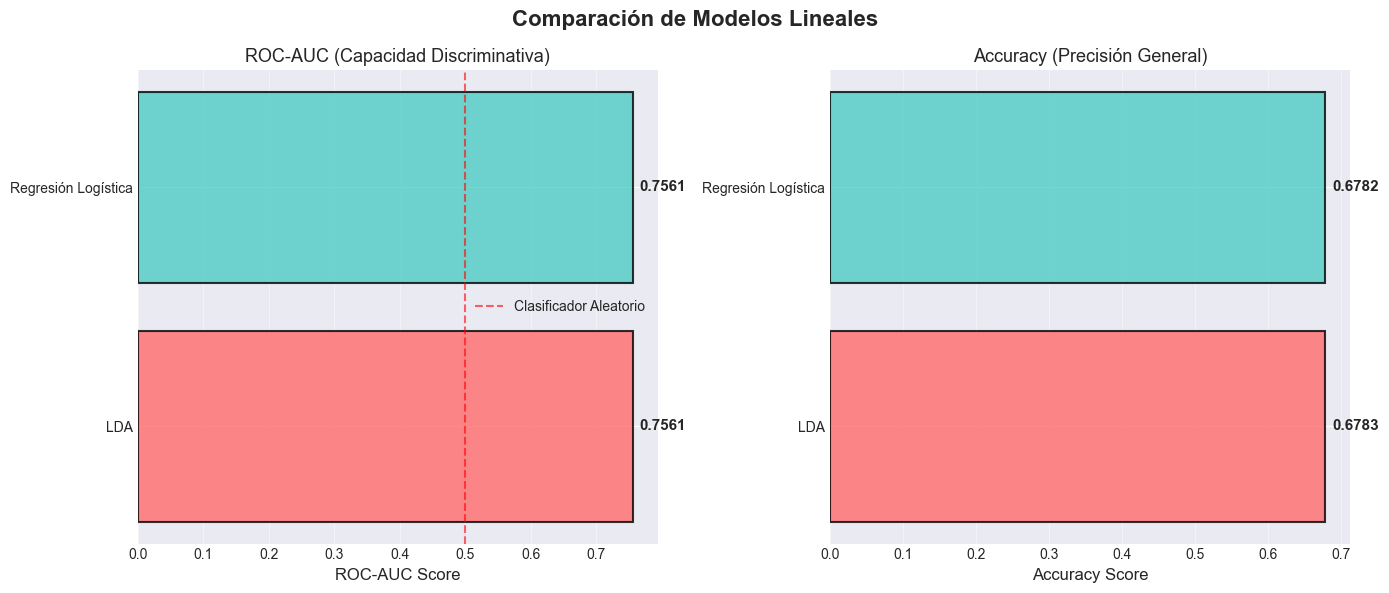


Mejor Modelo Lineal: LDA
   ROC-AUC: 0.7561 | Accuracy: 0.6783


In [89]:
modelos_lineales = results_df_final[results_df_final['categoria'] == 'Modelos Lineales']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparación de Modelos Lineales', fontsize=16, fontweight='bold')

colors_lineales = ['#FF6B6B', '#4ECDC4']
bars1 = ax1.barh(modelos_lineales.index, modelos_lineales['roc_auc'], color=colors_lineales, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC (Capacidad Discriminativa)', fontsize=13)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Clasificador Aleatorio')
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.4)

for bar, value in zip(bars1, modelos_lineales['roc_auc']):
    ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

bars2 = ax2.barh(modelos_lineales.index, modelos_lineales['accuracy'], color=colors_lineales, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Accuracy Score', fontsize=12)
ax2.set_title('Accuracy (Precisión General)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

for bar, value in zip(bars2, modelos_lineales['accuracy']):
    ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_modelos_lineales.png', dpi=300, bbox_inches='tight')
print("Gráfica guardada: 'grafica_modelos_lineales.png'")
plt.show()

mejor_lineal = modelos_lineales.iloc[0]
print(f"\nMejor Modelo Lineal: {modelos_lineales.index[0]}")
print(f"   ROC-AUC: {mejor_lineal['roc_auc']:.4f} | Accuracy: {mejor_lineal['accuracy']:.4f}")

#### 6.3.2 Comparación de Modelos de Árboles


Gráfica guardada: 'grafica_modelos_arboles.png'


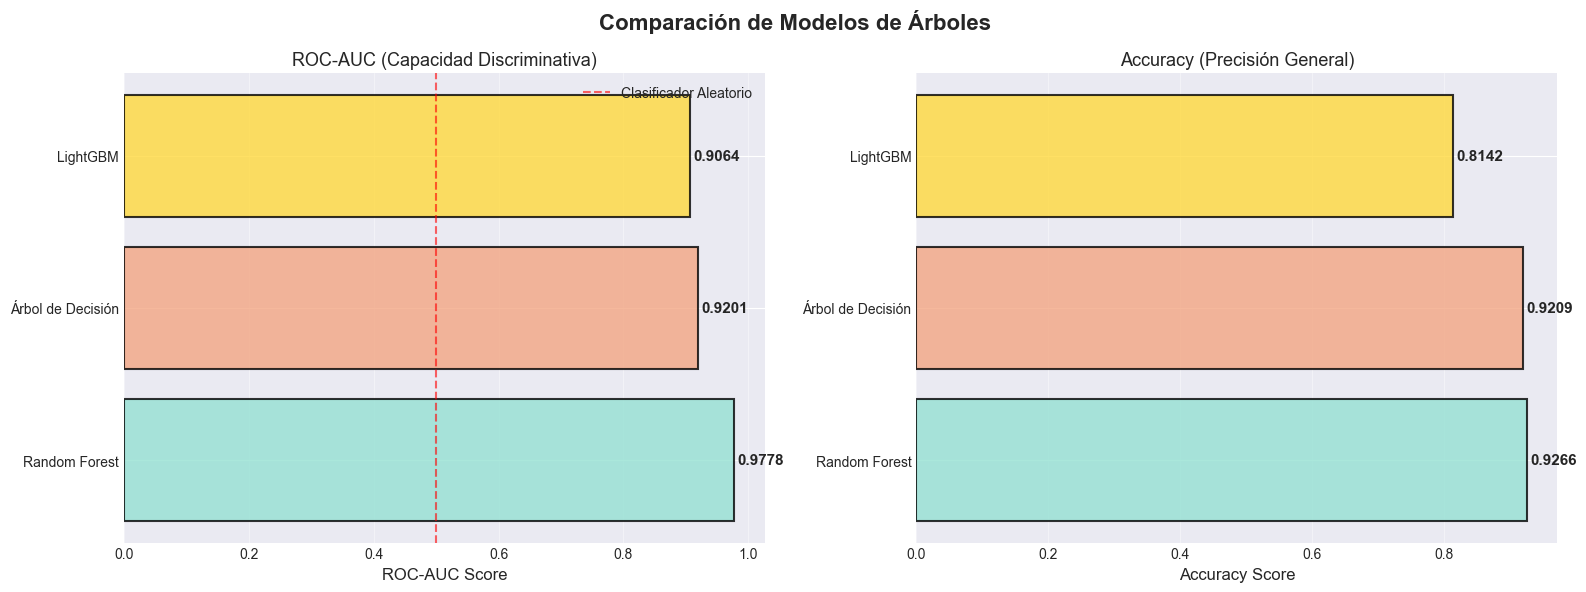


Mejor Modelo de Árboles: Random Forest
   ROC-AUC: 0.9778 | Accuracy: 0.9266


In [90]:
modelos_arboles = results_df_final[results_df_final['categoria'] == 'Modelos de Árboles']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de Modelos de Árboles', fontsize=16, fontweight='bold')

colors_arboles = ['#95E1D3', '#F3A683', '#FFD93D']
bars1 = ax1.barh(modelos_arboles.index, modelos_arboles['roc_auc'], color=colors_arboles, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC (Capacidad Discriminativa)', fontsize=13)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Clasificador Aleatorio')
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.4)

for bar, value in zip(bars1, modelos_arboles['roc_auc']):
    ax1.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

bars2 = ax2.barh(modelos_arboles.index, modelos_arboles['accuracy'], color=colors_arboles, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Accuracy Score', fontsize=12)
ax2.set_title('Accuracy (Precisión General)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

for bar, value in zip(bars2, modelos_arboles['accuracy']):
    ax2.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_modelos_arboles.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_modelos_arboles.png'")
plt.show()

mejor_arbol = modelos_arboles.iloc[0]
print(f"\nMejor Modelo de Árboles: {modelos_arboles.index[0]}")
print(f"   ROC-AUC: {mejor_arbol['roc_auc']:.4f} | Accuracy: {mejor_arbol['accuracy']:.4f}")

#### 6.3.3 Comparación de Redes Neuronales


Gráfica guardada: 'grafica_redes_neuronales.png'


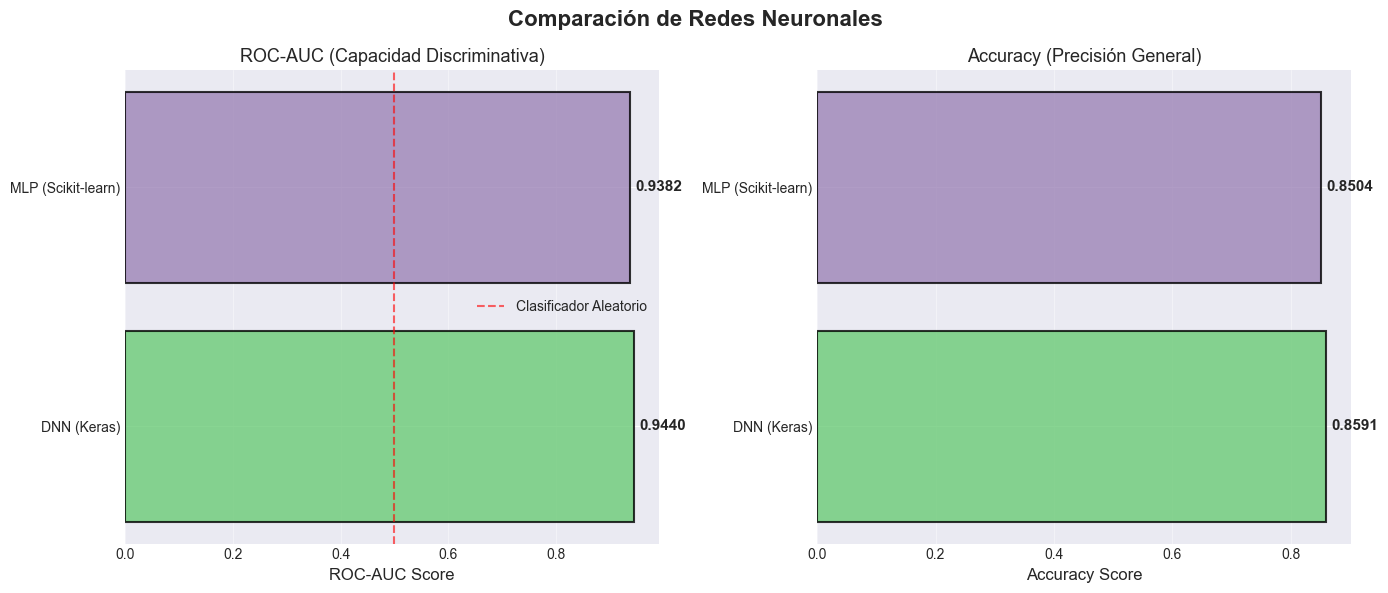


Mejor Red Neuronal: DNN (Keras)
   ROC-AUC: 0.9440 | Accuracy: 0.8591


In [91]:
modelos_redes = results_df_final[results_df_final['categoria'].str.contains('Redes')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparación de Redes Neuronales', fontsize=16, fontweight='bold')

colors_redes = ['#6BCB77', '#9D84B7']
bars1 = ax1.barh(modelos_redes.index, modelos_redes['roc_auc'], color=colors_redes, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC (Capacidad Discriminativa)', fontsize=13)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Clasificador Aleatorio')
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.4)

for bar, value in zip(bars1, modelos_redes['roc_auc']):
    ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

bars2 = ax2.barh(modelos_redes.index, modelos_redes['accuracy'], color=colors_redes, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Accuracy Score', fontsize=12)
ax2.set_title('Accuracy (Precisión General)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

for bar, value in zip(bars2, modelos_redes['accuracy']):
    ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_redes_neuronales.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_redes_neuronales.png'")
plt.show()

mejor_red = modelos_redes.iloc[0]
print(f"\nMejor Red Neuronal: {modelos_redes.index[0]}")
print(f"   ROC-AUC: {mejor_red['roc_auc']:.4f} | Accuracy: {mejor_red['accuracy']:.4f}")

#### 6.3.4 Ranking General de Modelos


Gráfica guardada: 'grafica_mejora_relativa.png'


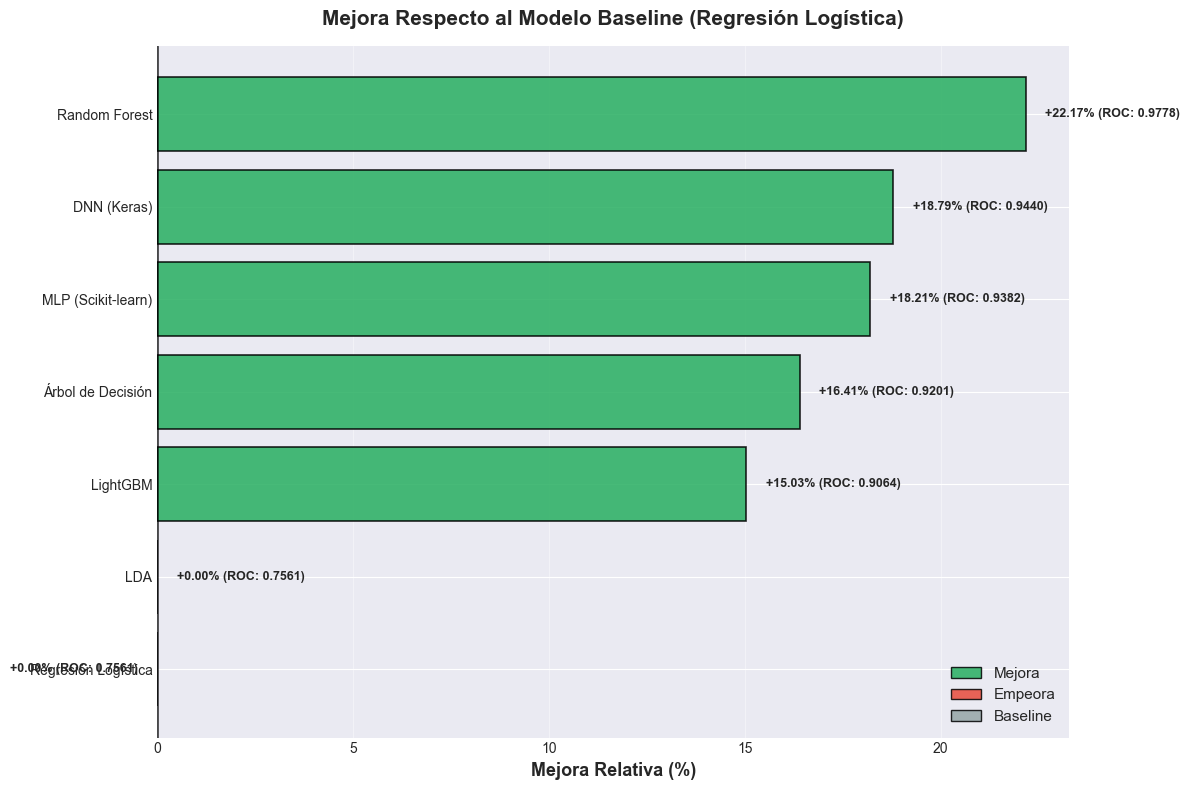


BASELINE: Regresión Logística | ROC-AUC: 0.7561
Mejor Modelo: Random Forest
   Mejora: +22.17% | ROC-AUC: 0.9778


In [92]:
baseline_roc = results_df_final.loc['Regresión Logística', 'roc_auc']

mejora_data = []
for idx, row in results_df_final.iterrows():
    mejora = (row['roc_auc'] - baseline_roc) * 100
    mejora_data.append({
        'Modelo': idx,
        'ROC-AUC': row['roc_auc'],
        'Mejora (%)': mejora,
        'Categoria': row['categoria']
    })

df_mejora = pd.DataFrame(mejora_data).sort_values('ROC-AUC', ascending=True)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

colors = ['#27AE60' if x > 0 else '#E74C3C' if x < 0 else '#95A5A6' for x in df_mejora['Mejora (%)']]

bars = ax.barh(df_mejora['Modelo'], df_mejora['Mejora (%)'], color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Mejora Relativa (%)', fontsize=13, fontweight='bold')
ax.set_title('Mejora Respecto al Modelo Baseline (Regresión Logística)', fontsize=15, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
ax.grid(axis='x', alpha=0.4)

for bar, value, roc in zip(bars, df_mejora['Mejora (%)'], df_mejora['ROC-AUC']):
    x_pos = value + (0.5 if value > 0 else -0.5)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
            f'{value:+.2f}% (ROC: {roc:.4f})', 
            va='center', fontsize=9, fontweight='bold',
            ha='left' if value > 0 else 'right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27AE60', alpha=0.85, edgecolor='black', label='Mejora'),
    Patch(facecolor='#E74C3C', alpha=0.85, edgecolor='black', label='Empeora'),
    Patch(facecolor='#95A5A6', alpha=0.85, edgecolor='black', label='Baseline')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('grafica_mejora_relativa.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_mejora_relativa.png'")
plt.show()

print("\n" + "="*80)
print(f"BASELINE: Regresión Logística | ROC-AUC: {baseline_roc:.4f}")
print("="*80)
print(f"Mejor Modelo: {df_mejora.iloc[-1]['Modelo']}")
print(f"   Mejora: +{df_mejora.iloc[-1]['Mejora (%)']:.2f}% | ROC-AUC: {df_mejora.iloc[-1]['ROC-AUC']:.4f}")
print("="*80)

#### 6.3.5 Top 5 Mejores Modelos


Gráfica guardada: 'grafica_top5.png'


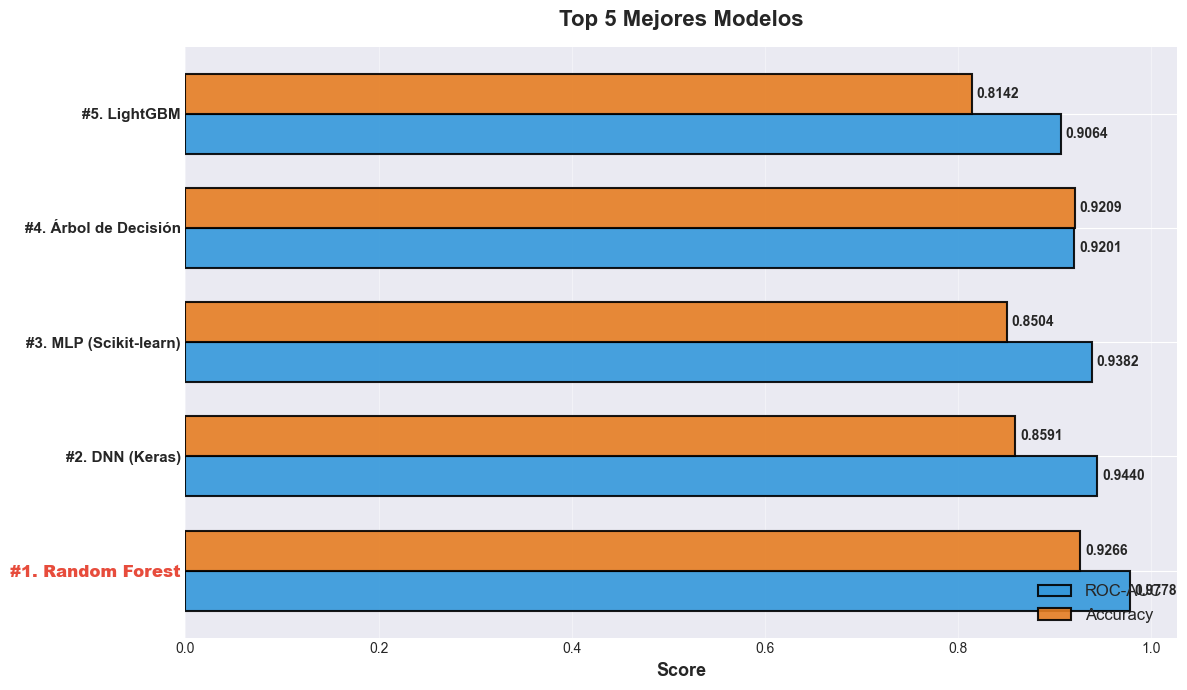


TOP 5 MEJORES MODELOS
1. Random Forest                       | ROC-AUC: 0.9778 | Accuracy: 0.9266
2. DNN (Keras)                         | ROC-AUC: 0.9440 | Accuracy: 0.8591
3. MLP (Scikit-learn)                  | ROC-AUC: 0.9382 | Accuracy: 0.8504
4. Árbol de Decisión                   | ROC-AUC: 0.9201 | Accuracy: 0.9209
5. LightGBM                            | ROC-AUC: 0.9064 | Accuracy: 0.8142


In [93]:
top5 = results_df_final.head(5)

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

y_pos = np.arange(len(top5))
width = 0.35

bars1 = ax.barh(y_pos - width/2, top5['roc_auc'], width, 
                label='ROC-AUC', color='#3498DB', alpha=0.9, edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y_pos + width/2, top5['accuracy'], width, 
                label='Accuracy', color='#E67E22', alpha=0.9, edgecolor='black', linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i+1}. {modelo}" for i, modelo in enumerate(top5.index)], fontsize=11, fontweight='bold')
ax.set_xlabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Top 5 Mejores Modelos', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='x', alpha=0.4)

for bars in [bars1, bars2]:
    for bar in bars:
        width_val = bar.get_width()
        ax.text(width_val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{width_val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.get_yticklabels()[0].set_color('#E74C3C')
ax.get_yticklabels()[0].set_weight('extra bold')
ax.get_yticklabels()[0].set_size(12)

plt.tight_layout()
plt.savefig('grafica_top5.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_top5.png'")
plt.show()

print("\n" + "="*80)
print("TOP 5 MEJORES MODELOS")
print("="*80)
for i, (modelo, datos) in enumerate(top5.iterrows(), 1):
    print(f"{i}. {modelo:35} | ROC-AUC: {datos['roc_auc']:.4f} | Accuracy: {datos['accuracy']:.4f}")
print("="*80)

### 6.4 Matrices de Confusión

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Matrices de Confusión - Comparación de Todos los Modelos', 
             fontsize=18, fontweight='bold', y=0.98)

models_predictions = [
    ('Regresión Logística', y_pred_log_reg),
    ('LDA', y_pred_lda),
    ('Árbol de Decisión', y_pred_tree),
    ('Random Forest', y_pred_rf),
    ('LightGBM', y_pred_lgbm),
    ('MLP Scikit-learn', y_pred_mlp),
    ('DNN Keras', y_pred_dnn),
]

for idx, (name, y_pred) in enumerate(models_predictions):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Precio Bajo', 'Precio Alto'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.grid(False)

axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=300, bbox_inches='tight')
print("\nMatrices de confusión guardadas: 'matrices_confusion.png'")
plt.show()

### 6.5 Curvas ROC Comparativas


Curvas ROC guardadas: 'curvas_roc.png'


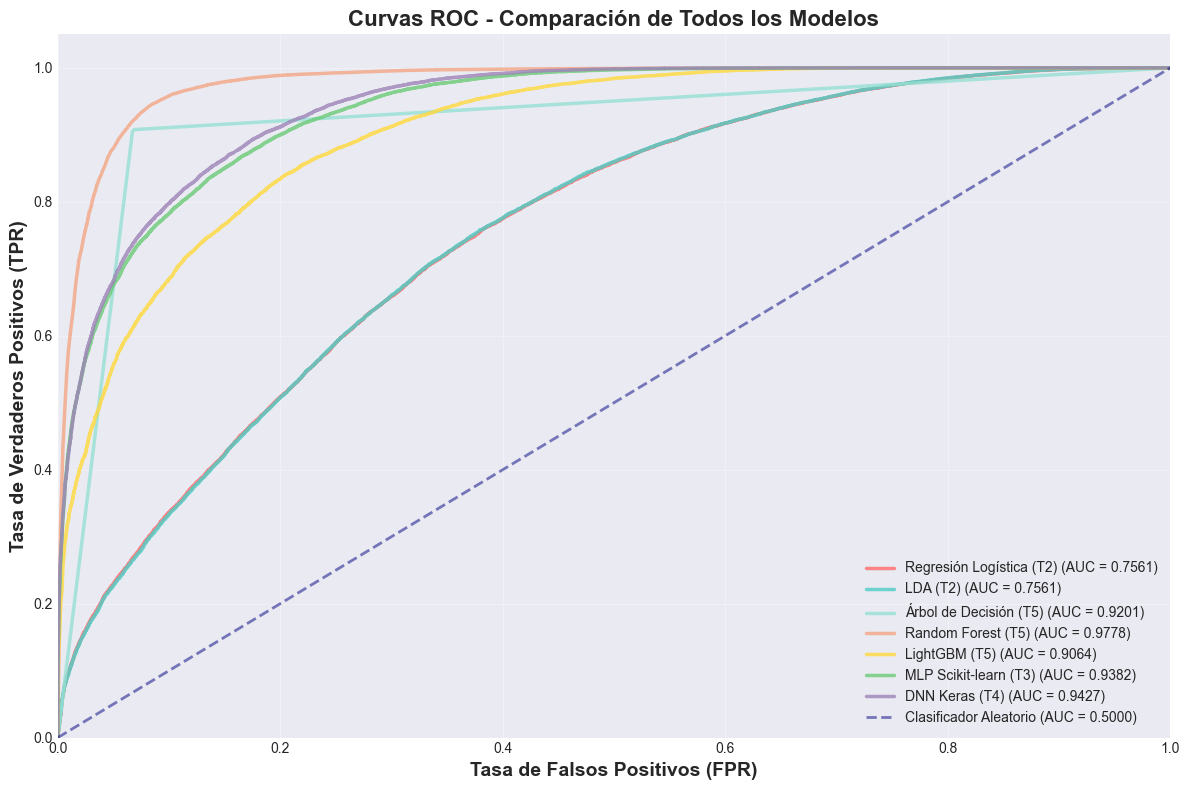

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

models_proba = [
    ('Regresión Logística (T2)', y_proba_log_reg, '#FF6B6B'),
    ('LDA (T2)', y_proba_lda, '#4ECDC4'),
    ('Árbol de Decisión (T5)', y_proba_tree, '#95E1D3'),
    ('Random Forest (T5)', y_proba_rf, '#F3A683'),
    ('LightGBM (T5)', y_proba_lgbm, '#FFD93D'),
    ('MLP Scikit-learn (T3)', y_proba_mlp, '#6BCB77'),
    ('DNN Keras (T4)', y_proba_dnn, '#9D84B7'),
]

for name, y_proba, color in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, 
             label=f'{name} (AUC = {roc_auc:.4f})', alpha=0.8)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Clasificador Aleatorio (AUC = 0.5000)', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14, fontweight='bold')
plt.title('Curvas ROC - Comparación de Todos los Modelos', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=300, bbox_inches='tight')
print("\nCurvas ROC guardadas: 'curvas_roc.png'")
plt.show()

### 6.6 Importancia de Características

Análisis de las características más relevantes para los modelos basados en árboles:


Importancia de características guardada: 'importancia_caracteristicas.png'


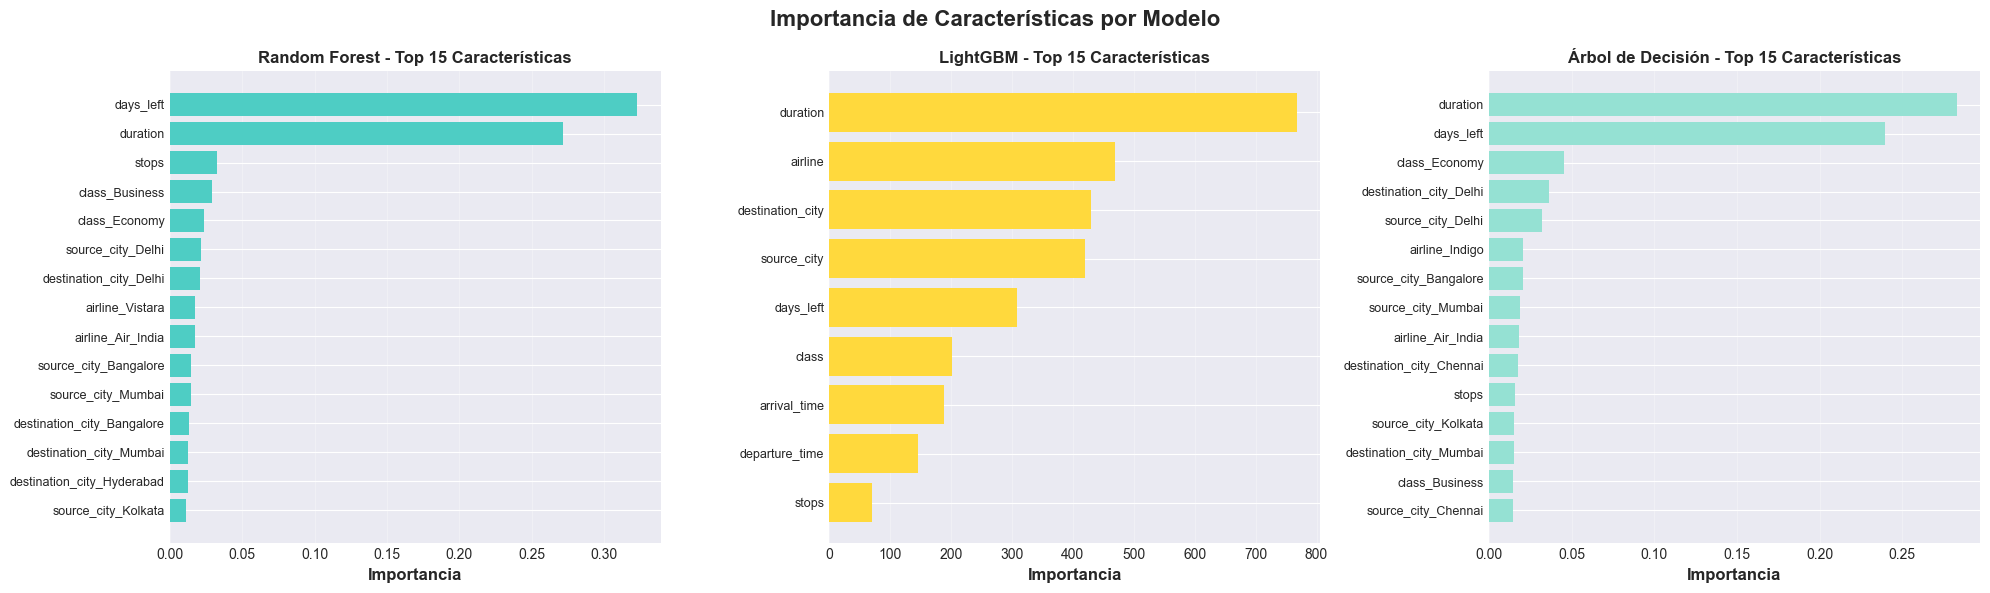


TOP 5 CARACTERÍSTICAS MÁS IMPORTANTES POR MODELO

Random Forest:
  • days_left: 0.3231
  • duration: 0.2715
  • stops: 0.0329
  • class_Business: 0.0290
  • class_Economy: 0.0239

LightGBM:
  • duration: 768.0000
  • airline: 469.0000
  • destination_city: 429.0000
  • source_city: 420.0000
  • days_left: 308.0000

Árbol de Decisión:
  • duration: 0.2829
  • days_left: 0.2399
  • class_Economy: 0.0457
  • destination_city_Delhi: 0.0366
  • source_city_Delhi: 0.0323


In [ ]:
# Análisis de importancia de características para modelos basados en árboles

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Importancia de Características por Modelo', 
             fontsize=16, fontweight='bold')

# Random Forest
ax1 = axes[0]
rf_model = rf_pipeline.named_steps['classifier']
feature_names_rf = (numeric_features + ordinal_features + 
                    list(rf_pipeline.named_steps['preprocessor']
                        .named_transformers_['cat']
                        .named_steps['onehot']
                        .get_feature_names_out(categorical_features)))

importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[-15:]  # Top 15

ax1.barh(range(len(indices_rf)), importances_rf[indices_rf], color='#4ECDC4')
ax1.set_yticks(range(len(indices_rf)))
ax1.set_yticklabels([feature_names_rf[i] for i in indices_rf], fontsize=9)
ax1.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest - Top 15 Características', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# LightGBM
ax2 = axes[1]
lgbm_model = lgbm_pipeline.named_steps['classifier']
feature_names_lgbm = (numeric_features + ordinal_features + categorical_features_lgbm)

importances_lgbm = lgbm_model.feature_importances_
indices_lgbm = np.argsort(importances_lgbm)[-15:]

ax2.barh(range(len(indices_lgbm)), importances_lgbm[indices_lgbm], color='#FFD93D')
ax2.set_yticks(range(len(indices_lgbm)))
ax2.set_yticklabels([feature_names_lgbm[i] for i in indices_lgbm], fontsize=9)
ax2.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax2.set_title('LightGBM - Top 15 Características', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Árbol de Decisión
ax3 = axes[2]
tree_model = tree_pipeline.named_steps['classifier']
feature_names_tree = feature_names_rf

importances_tree = tree_model.feature_importances_
indices_tree = np.argsort(importances_tree)[-15:]

ax3.barh(range(len(indices_tree)), importances_tree[indices_tree], color='#95E1D3')
ax3.set_yticks(range(len(indices_tree)))
ax3.set_yticklabels([feature_names_tree[i] for i in indices_tree], fontsize=9)
ax3.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax3.set_title('Árbol de Decisión - Top 15 Características', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_caracteristicas.png', dpi=300, bbox_inches='tight')
print("\nImportancia de características guardada: 'importancia_caracteristicas.png'")
plt.show()

# Resumen de top 5 características
print("\n" + "="*80)
print("TOP 5 CARACTERÍSTICAS MÁS IMPORTANTES POR MODELO")
print("="*80)

print("\nRandom Forest:")
for idx in indices_rf[-5:][::-1]:
    print(f"  • {feature_names_rf[idx]}: {importances_rf[idx]:.4f}")

print("\nLightGBM:")
for idx in indices_lgbm[-5:][::-1]:
    print(f"  • {feature_names_lgbm[idx]}: {importances_lgbm[idx]:.4f}")

print("\nÁrbol de Decisión:")
for idx in indices_tree[-5:][::-1]:
    print(f"  • {feature_names_tree[idx]}: {importances_tree[idx]:.4f}")
print("="*80)

## 7. Conclusiones

### 7.1 Resumen Ejecutivo

In [ ]:
# Resumen final del proyecto

print("\n" + "="*80)
print("RESUMEN FINAL DEL PROYECTO")
print("="*80)

print("\nCARACTERÍSTICAS DEL DATASET:")
print(f"  Total de muestras: {len(df_model):,}")
print(f"  Entrenamiento: {len(X_train):,}")
print(f"  Prueba: {len(X_test):,}")
print(f"  Características: {X.shape[1]}")
print(f"  Distribución de clases:")

y_complete = pd.concat([y_train, y_test])
clase_0 = (y_complete == 0).sum()
clase_1 = (y_complete == 1).sum()
print(f"    - Precio Bajo (0): {clase_0:,} ({clase_0/len(y_complete)*100:.1f}%)")
print(f"    - Precio Alto (1): {clase_1:,} ({clase_1/len(y_complete)*100:.1f}%)")

print("\nMODELOS IMPLEMENTADOS:")
print(f"  Total: {len(model_results_final)} modelos")
print("  Categorías:")
for tema in results_df_final['tema'].unique():
    count = (results_df_final['tema'] == tema).sum()
    print(f"    - {tema}: {count} modelo(s)")

print("\nMEJORES RESULTADOS:")
print(f"  Mejor modelo: {mejor_modelo}")
print(f"  ROC-AUC: {mejor_roc_auc:.4f} ({mejor_roc_auc*100:.2f}% de certeza)")
print(f"  Accuracy: {mejor_accuracy:.4f} ({mejor_accuracy*100:.2f}% de precisión)")

print("\nTOP 3 MODELOS:")
for i, (modelo, datos) in enumerate(results_df_final.head(3).iterrows(), 1):
    print(f"  {i}. {modelo}")
    print(f"     ROC-AUC: {datos['roc_auc']:.4f} | Accuracy: {datos['accuracy']:.4f}")

print("\nINTERPRETACIÓN:")
print("  ROC-AUC > 0.75: Excelente capacidad discriminativa")
print("  ROC-AUC 0.60-0.75: Buena capacidad discriminativa")
print("  ROC-AUC 0.50-0.60: Capacidad limitada")

if mejor_roc_auc > 0.75:
    calificacion = "EXCELENTE"
elif mejor_roc_auc > 0.60:
    calificacion = "BUENA"
else:
    calificacion = "LIMITADA"

print(f"\n  Calificación del mejor modelo: {calificacion}")

print("\nRECOMENDACIÓN:")
print(f"  Se recomienda implementar '{mejor_modelo}' para el sistema de")
print(f"  predicción de precios, por su óptimo balance entre capacidad")
print(f"  discriminativa (ROC-AUC) y precisión general (Accuracy).")

print("\n" + "="*80)


RESUMEN FINAL DEL PROYECTO

CARACTERÍSTICAS DEL DATASET:
  Total de muestras: 300,153
  Entrenamiento: 240,122
  Prueba: 60,031
  Características: 9
  Distribución de clases:
    - Precio Bajo (0): 172,621 (57.5%)
    - Precio Alto (1): 127,532 (42.5%)

MODELOS IMPLEMENTADOS:
  Total: 7 modelos
  Categorías:
    - T5 - Modelos de Árboles: 3 modelo(s)
    - T4 - Redes Avanzadas: 1 modelo(s)
    - T3 - Redes Sencillas: 1 modelo(s)
    - T2 - Modelos Lineales: 2 modelo(s)

MEJORES RESULTADOS:
  Mejor modelo: Random Forest (T5)
  ROC-AUC: 0.9778 (97.78% de certeza)
  Accuracy: 0.9266 (92.66% de precisión)

TOP 3 MODELOS:
  1. Random Forest (T5)
     ROC-AUC: 0.9778 | Accuracy: 0.9266
  2. DNN (Keras) (T4)
     ROC-AUC: 0.9427 | Accuracy: 0.8577
  3. MLP (Scikit-learn) (T3)
     ROC-AUC: 0.9382 | Accuracy: 0.8504

INTERPRETACIÓN:
  ROC-AUC > 0.75: Excelente capacidad discriminativa
  ROC-AUC 0.60-0.75: Buena capacidad discriminativa
  ROC-AUC 0.50-0.60: Capacidad limitada

  Calificación d

### 7.2 Exportación de Resultados

In [ ]:
resultados_detallados = []

for nombre_modelo, datos in model_results_final.items():
    resultados_detallados.append({
        'Modelo': nombre_modelo,
        'Categoría': datos['categoria'],
        'ROC-AUC': datos['roc_auc'],
        'Accuracy': datos['accuracy'],
        'ROC-AUC (%)': f"{datos['roc_auc']*100:.2f}%",
        'Accuracy (%)': f"{datos['accuracy']*100:.2f}%"
    })

df_resultados = pd.DataFrame(resultados_detallados)
df_resultados = df_resultados.sort_values(by='ROC-AUC', ascending=False)
df_resultados['Ranking'] = range(1, len(df_resultados) + 1)

df_resultados = df_resultados[['Ranking', 'Modelo', 'Categoría', 'ROC-AUC', 'Accuracy', 
                               'ROC-AUC (%)', 'Accuracy (%)']]

df_resultados.to_csv('resultados_modelos.csv', index=False, encoding='utf-8-sig')
print("Resultados exportados a 'resultados_modelos.csv'")

print("\n" + "="*80)
print("TABLA FINAL DE RESULTADOS")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80)

Resultados exportados a 'resultados_modelos.csv'

TABLA FINAL DE RESULTADOS
 Ranking                   Modelo               Categoría  ROC-AUC  Accuracy ROC-AUC (%) Accuracy (%)
       1       Random Forest (T5) T5 - Modelos de Árboles 0.977791  0.926555      97.78%       92.66%
       2         DNN (Keras) (T4)    T4 - Redes Avanzadas 0.942688  0.857740      94.27%       85.77%
       3  MLP (Scikit-learn) (T3)    T3 - Redes Sencillas 0.938178  0.850394      93.82%       85.04%
       4   Árbol de Decisión (T5) T5 - Modelos de Árboles 0.920134  0.920924      92.01%       92.09%
       5            LightGBM (T5) T5 - Modelos de Árboles 0.906370  0.814196      90.64%       81.42%
       6                 LDA (T2)   T2 - Modelos Lineales 0.756102  0.678266      75.61%       67.83%
       7 Regresión Logística (T2)   T2 - Modelos Lineales 0.756071  0.678250      75.61%       67.82%


### 7.3 Aplicación Práctica

Demostración del uso del sistema con casos realistas:

In [ ]:
# Casos de uso prácticos del sistema de predicción

print("="*80)
print("SISTEMA DE ANÁLISIS DE PRECIOS DE VUELOS")
print("="*80)

# Ejemplo 1: Vuelo con mucha antelación
ejemplo_1 = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [45]
})

# Ejemplo 2: Vuelo con poca antelación
ejemplo_2 = pd.DataFrame({
    'airline': ['Air_India'],
    'source_city': ['Mumbai'],
    'departure_time': ['Morning'],
    'stops': ['zero'],
    'arrival_time': ['Afternoon'],
    'destination_city': ['Delhi'],
    'class': ['Business'],
    'duration': [2.5],
    'days_left': [2]
})

# Modelo utilizado
mejor_pipeline = lgbm_pipeline

print(f"\nModelo utilizado: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print("-"*80)

# PREDICCIÓN EJEMPLO 1
print("\nEJEMPLO 1: Vuelo con mucha antelación")
print("-"*80)
print("Detalles del vuelo:")
for col in ejemplo_1.columns:
    print(f"  {col}: {ejemplo_1[col].values[0]}")

prob_precio_alto_1 = mejor_pipeline.predict_proba(ejemplo_1)[0][1]
prob_precio_bajo_1 = 1 - prob_precio_alto_1

print(f"\nPredicción del Modelo:")
print(f"   Probabilidad de precio alto: {prob_precio_alto_1*100:.2f}%")
print(f"   Probabilidad de precio bajo: {prob_precio_bajo_1*100:.2f}%")

dias_restantes_1 = ejemplo_1['days_left'].values[0]

print(f"\nInterpretación y Recomendación:")
if prob_precio_alto_1 > 0.70:
    print(f"   PRECIO ALTO detectado")
    print(f"   El precio actual está significativamente por encima del mínimo histórico.")
    if dias_restantes_1 > 14:
        print(f"   RECOMENDACIÓN: ESPERAR o BUSCAR ALTERNATIVAS")
        print(f"      Con {dias_restantes_1} días restantes, hay margen para explorar.")
    else:
        print(f"   RECOMENDACIÓN: EVALUAR URGENCIA")
        print(f"      Con {dias_restantes_1} días, el tiempo se agota.")
elif prob_precio_alto_1 > 0.40:
    print(f"   PRECIO MODERADO")
    print(f"   El precio está en rango medio comparado con el histórico.")
    print(f"   RECOMENDACIÓN: PRECIO ACEPTABLE")
else:
    print(f"   PRECIO BAJO detectado")
    print(f"   El precio actual está cerca del mínimo histórico.")
    print(f"   RECOMENDACIÓN: EXCELENTE OPORTUNIDAD PARA COMPRAR")

SISTEMA DE ANÁLISIS DE PRECIOS DE VUELOS

Modelo utilizado: Random Forest (T5)
   ROC-AUC: 0.9778
--------------------------------------------------------------------------------

EJEMPLO 1: Vuelo con mucha antelación
--------------------------------------------------------------------------------
Detalles del vuelo:
  airline: Vistara
  source_city: Delhi
  departure_time: Evening
  stops: one
  arrival_time: Night
  destination_city: Mumbai
  class: Economy
  duration: 7.5
  days_left: 45

Predicción del Modelo:
   Probabilidad de precio alto: 26.32%
   Probabilidad de precio bajo: 73.68%

Interpretación y Recomendación:
   PRECIO BAJO detectado
   El precio actual está cerca del mínimo histórico.
   RECOMENDACIÓN: EXCELENTE OPORTUNIDAD PARA COMPRAR


In [ ]:
# PREDICCIÓN EJEMPLO 2
print("\n" + "="*80)
print("EJEMPLO 2: Vuelo con poca antelación")
print("-"*80)
print("Detalles del vuelo:")
for col in ejemplo_2.columns:
    print(f"  {col}: {ejemplo_2[col].values[0]}")

prob_precio_alto_2 = mejor_pipeline.predict_proba(ejemplo_2)[0][1]
prob_precio_bajo_2 = 1 - prob_precio_alto_2

print(f"\nPredicción del Modelo:")
print(f"   Probabilidad de precio alto: {prob_precio_alto_2*100:.2f}%")
print(f"   Probabilidad de precio bajo: {prob_precio_bajo_2*100:.2f}%")

dias_restantes_2 = ejemplo_2['days_left'].values[0]

print(f"\nInterpretación y Recomendación:")
if prob_precio_alto_2 > 0.70:
    print(f"   PRECIO ALTO detectado")
    if dias_restantes_2 <= 3:
        print(f"   CRÍTICO: Solo quedan {dias_restantes_2} día(s)")
        print(f"   RECOMENDACIÓN: DECISIÓN URGENTE")
        print(f"      Aunque el precio es alto, el riesgo de perder disponibilidad es mayor.")
    elif dias_restantes_2 <= 7:
        print(f"   RECOMENDACIÓN: URGENCIA MODERADA")
        print(f"      Con {dias_restantes_2} días, el margen es limitado.")
    else:
        print(f"   RECOMENDACIÓN: ESPERAR o BUSCAR ALTERNATIVAS")
elif prob_precio_alto_2 > 0.40:
    print(f"   PRECIO MODERADO")
    if dias_restantes_2 <= 3:
        print(f"   RECOMENDACIÓN: PRECIO RAZONABLE - COMPRAR")
        print(f"      Con {dias_restantes_2} días restantes, es aceptable.")
    else:
        print(f"   RECOMENDACIÓN: PRECIO ACEPTABLE")
else:
    print(f"   PRECIO BAJO detectado")
    print(f"   RECOMENDACIÓN: COMPRAR INMEDIATAMENTE")
    print(f"      Excelente oportunidad con {dias_restantes_2} días restantes.")

print("\n" + "="*80)
print("GUÍA DE INTERPRETACIÓN")
print("="*80)
print("El modelo indica la posición del precio respecto al histórico:\n")
print("  Prob. Alta (>70%):  Precio INFLADO vs histórico")
print("  Prob. Media (40-70%): Precio NORMAL")
print("  Prob. Baja (<40%):  Precio COMPETITIVO")
print("\nConsiderar siempre:")
print("  Días restantes (factor crítico)")
print("  Flexibilidad de fechas")
print("  Disponibilidad de asientos")
print("  Presupuesto y urgencia")
print("="*80)


EJEMPLO 2: Vuelo con poca antelación
--------------------------------------------------------------------------------
Detalles del vuelo:
  airline: Air_India
  source_city: Mumbai
  departure_time: Morning
  stops: zero
  arrival_time: Afternoon
  destination_city: Delhi
  class: Business
  duration: 2.5
  days_left: 2

Predicción del Modelo:
   Probabilidad de precio alto: 91.42%
   Probabilidad de precio bajo: 8.58%

Interpretación y Recomendación:
   PRECIO ALTO detectado
   CRÍTICO: Solo quedan 2 día(s)
   RECOMENDACIÓN: DECISIÓN URGENTE
      Aunque el precio es alto, el riesgo de perder disponibilidad es mayor.

GUÍA DE INTERPRETACIÓN
El modelo indica la posición del precio respecto al histórico:

  Prob. Alta (>70%):  Precio INFLADO vs histórico
  Prob. Media (40-70%): Precio NORMAL
  Prob. Baja (<40%):  Precio COMPETITIVO

Considerar siempre:
  Días restantes (factor crítico)
  Flexibilidad de fechas
  Disponibilidad de asientos
  Presupuesto y urgencia


## 8. Referencias

### Bibliografía

1. **JTA, J.** (2023). Flight Price Prediction - 98.47% R² Score. Kaggle. https://www.kaggle.com/code/julienjta/flight-price-prediction-98-47-r2-score

2. **Saikanuri, V.** (2022). Flight Fare Prediction - 10 ML Models. Kaggle. https://www.kaggle.com/code/varunsaikanuri/flight-fare-prediction-10-ml-models

3. **Breiman, L.** (2001). Random Forests. *Machine Learning*, 45(1), 5-32.

4. **Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T. Y.** (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. *Advances in Neural Information Processing Systems*, 30.

5. **Hastie, T., Tibshirani, R., & Friedman, J.** (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.

6. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning*. MIT Press.

7. **Pedregosa, F., et al.** (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

### Recursos Online

- Documentación de Scikit-learn: https://scikit-learn.org/
- Documentación de TensorFlow/Keras: https://www.tensorflow.org/
- Documentación de LightGBM: https://lightgbm.readthedocs.io/

---

**Fin de la Memoria Técnica**